In [1]:
#Rank-based linear factor model for SP500
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import yfinance as yf
import requests

#Getting top 500 companies from wiki
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
}

html = requests.get(url, headers=headers).text

sp500 = pd.read_html(html)[0]
tickers = sp500["Symbol"].str.replace(".", "-", regex=False).tolist()  # BRK.B -> BRK-B for yfinance

data = [] 

#Storing the companies' data in a list
for t in tickers:
    try:
        info = yf.Ticker(t).info
        data.append({
            "ticker": t,
            "earnings_yield": info.get("trailingEps", None) / info.get("priceToBook", None),
            "roc": info.get("returnOnAssets", None),
            "volatility": info.get("beta", None)
        })
    except:
        pass

#Ranking the data
df = pd.DataFrame(data).dropna()
df["rank_earnings_yield"] = df["earnings_yield"].rank(ascending=False)
df["rank_roc"] = df["roc"].rank(ascending=False)
df["rank_volatility"] = df["volatility"].rank(ascending=True)

#Creating the ranking values for the algo
signs = {
    "rank_earnings_yield": +1,
    "rank_roc": +1,
    "rank_volatility": -1
}

#Calculating the final Ranks for the companies
df["final_rank"] = sum(signs[col] * df[col] for col in signs)

df = df.sort_values("final_rank", ascending=False)

top_30 = df.head(30)
print(top_30[["ticker", "final_rank"]])


    ticker  final_rank
93     CNC       868.0
274    KHC       836.0
154    DOW       790.0
413    SJM       786.0
59     BAX       768.0
10     APD       764.0
292    LYB       763.5
432   TTWO       750.0
317    TAP       746.5
127   CSGP       740.0
117    CAG       734.0
472   VTRS       732.5
457    UDR       715.0
134    CVS       715.0
303    MCK       714.0
85     CAH       710.5
445    TKO       694.0
314   MRNA       675.0
466    VTR       668.0
92     COR       668.0
251     IP       665.0
250    IFF       651.0
130   CRWD       642.5
365    PCG       641.5
79     BXP       628.5
23    AMCR       628.0
356   PANW       625.0
232    HRL       612.0
94     CNP       604.5
487   WELL       597.0


### Hypothesis Testing Steps

1. Based on a backtest on some finite sample of data, we compute a certain statistical measure called the test statistic. For concreteness, lets say the test statistic is the average daily return of a trading strategy in that period.

2. We suppose that the true average daily return based on an infinite data set is actually zero. This supposition is called the null hypothesis.

3. We suppose that the probability distribution of daily returns is known. The probability distribution has a zero mean, based on the null hypothesis. We describe later how we determine this probability distribution.

4. Based on this null hypothesis probability distribution, we compute the probability p that the average daily returns will be at least as large as the observered value in the backtest. This probability p is called the p-value and if it is very small (smaller than 0.01), that means we can "reject the null hypothesis", and conclude that the backtested average daily return is statistically significant.

## Regime Identification: Mean Reversion vs Trend

Before applying any trading strategy, it is essential to understand the statistical behavior of a price series.

---

### 1. Augmented Dickey–Fuller (ADF) Test
The ADF test checks whether a price series contains a unit root, which would indicate random-walk behavior. This test is based on the regression: Δy_t = α + λ y_{t-1} + ε_t

---

The null hypothesis is \( \lambda = 0 \), meaning that price changes are independent of the current price level. Rejecting this hypothesis suggests the series is **stationary**, which is a necessary condition for mean reversion.

In practice, individual stocks often fail the ADF test due to structural changes, growth, and regime shifts. Therefore, the ADF test is used here primarily as a **statistical reference**, not as a strict trading filter.

### 2. Lambda (λ) and Half-Life of Mean Reversion
Even when the ADF test does not reject the random-walk hypothesis, the estimated value of \( \lambda \) still provides valuable economic insight. The coefficient \( \lambda \) measures how strongly price changes respond to deviations from the mean:

- \( \lambda < 0 \): mean-reverting behavior  
- \( \lambda > 0 \): trending behavior  

Interpreting the regression as an Ornstein–Uhlenbeck process allows us to compute the **half-life of mean reversion**:

\[
\text{Half-life} = \frac{-\ln(2)}{\lambda}
\]

The half-life represents the expected time for a price deviation to decay by 50%. Short half-lives indicate strong and potentially tradable mean reversion, while long half-lives suggest that mean-reversion strategies may be impractical.


### 3. Hurst Exponent
The Hurst exponent measures how the variance of price changes scales with time:

\[
\mathrm{Var}[z(t+\tau) - z(t)] \sim \tau^{2H}
\]

Interpretation:
- \( H = 0.5 \): random walk  
- \( H < 0.5 \): mean reversion  
- \( H > 0.5 \): trending behavior  

Unlike the ADF test, the Hurst exponent captures **long-range dependence** and provides a complementary, scale-based view of market behavior.

### 4. Strategy Interpretation
No single test is decisive on its own. Instead, these diagnostics should be interpreted together:

- **ADF**: statistical evidence against random walk (strict but informative)
- **λ and half-life**: economic usefulness and trading time scale
- **Hurst exponent**: persistence vs anti-persistence across horizons

If λ is negative with a reasonably short half-life and the Hurst exponent is below 0.5, a **mean-reversion strategy** may be appropriate. If λ is positive or the Hurst exponent is above 0.5, a **trend-following strategy** is more suitable. When signals are weak or contradictory, the asset may be close to a random walk, and caution is warranted.

---

### Key Takeaway
The goal of these tests is not to “prove” a strategy, but to **avoid applying the wrong strategy to the wrong market regime**. Understanding regime behavior is a critical first step in systematic trading and helps guide both strategy selection and parameter choices.

In [2]:
#Running ADF, Hurst, and Mean-life test to determine what strategy
#to decide between Mean Reversion vs Trend strategies 

import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

ticker = "AAPL"
prices = yf.download(ticker,start="2018-01-01", auto_adjust=True, progress=False)["Close"].dropna()
logp = np.log(prices)

print(f"{ticker} data points:", len(logp))

#ADF TEST
# PURPOSE:
# The ADF test checks whether the price series behaves like
# a RANDOM WALK (unit root) or is STATIONARY.
#
# Model tested (simplified):
# Δy_t = λ y_{t-1} + μ + ε_t
#
# Null hypothesis (H0):
#   λ = 0  → random walk (no mean reversion)
#
# Alternative hypothesis (H1):
#   λ < 0 → mean reverting
#
# We test this using the t-statistic of λ against
# Dickey-Fuller critical values.

adf_stat, adf_p, adf_lags, adf_nobs, adf_crit = adfuller(
    logp, maxlag=1, regression="c", autolag=None
)

print("\n--- ADF Test on log(price) ---")
print("ADF statistic:", adf_stat)
print("p-value:", adf_p)
print("lags used:", adf_lags)
print("critical values:", adf_crit)

# INTERPRETATION:
# If ADF statistic < critical value → reject random walk
# In practice, single stocks usually FAIL ADF

#Lambda + Half-life calculation
# PURPOSE:
# Even if ADF fails, traders still want to know:
# "How fast does the price mean-revert?"
#
# We estimate λ directly using the regression:
#
# Δy_t = α + λ y_{t-1} + ε_t
#
# λ < 0 → mean reversion
# λ > 0 → trending behavior
#
# From Ornstein-Uhlenbeck theory, the HALF-LIFE of mean
# reversion is:
#
#   half_life = -ln(2) / λ

# First difference: Δy_t = y_t - y_{t-1}
dy = logp.diff().dropna()
y_lag = logp.shift(1).dropna()
dy = dy.loc[y_lag.index]

X = sm.add_constant(y_lag)
ols = sm.OLS(dy,X).fit()

lambda_hat = ols.params[1]
lambda_se = ols.bse[1]
lambda_t = lambda_hat / lambda_se

half_life = (-np.log(2) / lambda_hat) if lambda_hat < 0 else np.inf

print("\n--- Lambda (λ) + Half-life ---")
print("lambda_hat:", lambda_hat)
print("SE(lambda):", lambda_se)
print("t-stat (lambda/SE):", lambda_t)
print("half_life (days):", half_life)

# INTERPRETATION:
# λ > 0        → trending (momentum strategies)
# λ < 0        → mean reverting
# half-life:
#   < 20 days  → strong mean reversion
#   20–50 days → weak but tradable
#   > 100 days → impractical

#Hurst exponent
# PURPOSE:
# Measures how variance scales with time:
#
# Var[z(t+τ) - z(t)] ~ τ^(2H)
#
# H = 0.5 → random walk
# H < 0.5 → mean reversion
# H > 0.5 → trending
#
# This is a COMPLEMENT to ADF (not a replacement).
def hurst_exponent(x, max_lag=100):
    x = np.asarray(x).reshape(-1)  # force 1D, avoids (N,1) shape issues too
    max_lag = min(max_lag, len(x) - 2)

    lags = range(2, max_lag + 1)

    # RMS of lagged differences: sqrt(E[(x_t - x_{t-lag})^2])
    tau = [np.sqrt(np.mean((x[lag:] - x[:-lag])**2)) for lag in lags]

    # slope of log(tau) vs log(lag) is H
    poly = np.polyfit(np.log(list(lags)), np.log(tau), 1)
    return poly[0]


H = hurst_exponent(logp.values, max_lag=100)
print("\n--- Hurst Exponent ---")
print("H:", H)

# INTERPRETATION:
# H < 0.5 → mean reverting
# H ≈ 0.5 → random walk
# H > 0.5 → trending


print("\n--- Quick Interpretation ---")
if lambda_hat > 0:
    print("λ > 0 → trending bias (momentum/trend-following more appropriate).")
elif np.isfinite(half_life) and half_life < 30:
    print("λ < 0 with half-life < ~30 days → mean reversion may be tradable.")
else:
    print("λ ≤ 0 but half-life is long or λ ~ 0 → weak mean reversion / near random walk.")
print("H < 0.5 suggests mean reversion; H > 0.5 suggests trending; H ≈ 0.5 suggests random walk.")
print("ADF p-value small (e.g., <0.05) would support stationarity, but stocks often fail ADF.")

AAPL data points: 2004

--- ADF Test on log(price) ---
ADF statistic: -1.0472890022147334
p-value: 0.7356285836601645
lags used: 1
critical values: {'1%': np.float64(-3.433620581635353), '5%': np.float64(-2.862984767669893), '10%': np.float64(-2.5675391324160355)}

--- Lambda (λ) + Half-life ---
lambda_hat: -0.0007694937632223154
SE(lambda): 0.000720874306025631
t-stat (lambda/SE): -1.0674451243306704
half_life (days): 900.7833639318104

--- Hurst Exponent ---
H: 0.5266752413738331

--- Quick Interpretation ---
λ ≤ 0 but half-life is long or λ ~ 0 → weak mean reversion / near random walk.
H < 0.5 suggests mean reversion; H > 0.5 suggests trending; H ≈ 0.5 suggests random walk.
ADF p-value small (e.g., <0.05) would support stationarity, but stocks often fail ADF.


## Cointegration

Finding a linear combination of non-stationary price series that is stationary, and then designing a trading strategy that exploits the mean-reverting behavior of that combination.

---

### Cointegrated Augmented Dickey-Fuller (CADF) Test 

A two-step procedure used to test for cointegration between two non-stationary time series. First, one price series is regressed on the other to estimate a hedge ratio and form a spread. Second, and Augmented Dickey-Fuller test is applied to this residual to determine whether the spread is stationary. If the residual is stationary, the two series are said to be cointegrated. A key limitation of the CADF test is that it is order-dependent-regressing Y on X may yield on a different result than regressing X on Y-and it can identify only one cointegrating relationship. For this reason, CASD is most commonly used in pairs trading and simple relative-value strategies.

---

### Johansen Test

A multivariate method for detecting cointegration among two or more non-stationary time series. It is based on a vector autoregression (VAR) framework and treats all variables symmetrically, making it order-independent. Rather than testing a single spread, the Johansen test determines the number of cointegrating relationships and produces the coressponding hedge ratios as eigenvectors. This allows multiple independent stationary portfolios to be identified from the same set of assets. Because of its ability to handle higher-dimensional systems and uncover all cointegration relations at once, the Johasen test is widely used in multi-asset statistical arbitrage and portfolio construction. 

In [3]:
#CADF
# Many price series (and log prices) behave like random walks (non-stationary).
# If X_t and Y_t are *cointegrated*, then there exists a hedge ratio beta such that:
#
#     spread_t = Y_t - (alpha + beta * X_t)
#
# is *stationary* (mean-reverting).
#
# Engle–Granger / CADF is:
#   (1) Estimate alpha, beta via OLS regression
#   (2) Test the residual spread for stationarity using ADF
#
# If the spread is stationary, that’s evidence of cointegration.
x_ticker = "KO"
y_ticker = "PEP"

start = "2018-01-01"
px = yf.download([x_ticker,y_ticker], start=start, auto_adjust=True,progress=False)["Close"].dropna()

logX = np.log(px[x_ticker])
logY = np.log(px[y_ticker])

# 2) OLS regression: logy = alpha + beta*logx + error
# ------------------------------------------------------------
# OLS = Ordinary Least Squares:
# It chooses alpha and beta to minimize the SUM of squared residuals:
#
#     minimize over (alpha, beta):  Σ_t (logy_t - (alpha + beta*logx_t))^2
#
# The resulting fitted line gives:
#   - beta: slope (interpreted as hedge ratio)
#   - alpha: intercept (constant offset between the two series)

X = sm.add_constant(logX)
# add_constant adds a column of 1s so the regression can estimate alpha (intercept).
# Without it, you'd be forcing alpha=0 (line through origin), often unrealistic.

model = sm.OLS(logY,X).fit()

alpha,beta = model.params["const"], model.params[x_ticker]

print("Regression (logy ~ alpha + beta*logx)")
print(f"alpha = {alpha:.6f}")
print(f"beta  = {beta:.6f}")

spread = logY - (alpha + beta * logX)

adf_stat, p_value, used_lags, nobs, crit_vals, icbest = adfuller(
    spread.dropna(),
    regression="c",
    autolag="AIC"
)

print("\nADF test on spread (residuals)")
print(f"ADF statistic = {adf_stat:.4f}")
print(f"p-value       = {p_value:.4f}")
print(f"lags used     = {used_lags}")
print("critical values:", crit_vals)

# 5) Interpreting ADF outputs
# ------------------------------------------------------------
# ADF statistic:
# - More negative => stronger evidence against unit root (more evidence of stationarity)
#
# Critical values:
# - thresholds for the ADF stat at common significance levels (1%, 5%, 10%)
# - If ADF stat is LESS than (more negative than) the 5% critical value,
#   reject H0 at 5% significance.
#
# p-value:
# - another way to decide rejection
# - p-value < 0.05 -> reject H0 (evidence spread is stationary)
#
# Lags used:
# - ADF includes lagged Δspread terms to account for autocorrelation
# - too few lags -> test may be invalid (residual autocorrelation)
# - too many lags -> lose power / fewer effective observations


Regression (logy ~ alpha + beta*logx)
alpha = 1.461428
beta  = 0.869959

ADF test on spread (residuals)
ADF statistic = -1.5096
p-value       = 0.5287
lags used     = 2
critical values: {'1%': np.float64(-3.433622218212895), '5%': np.float64(-2.8629854902259004), '10%': np.float64(-2.5675395171404802)}


In [4]:
#JohansenTest
# Johansen tests cointegration among 2+ non-stationary time series.
# It answers:
#   - How many cointegrating relationships exist? (the "rank")
#   - What are the hedge ratios (cointegrating vectors) for each relationship?
#
# Compared to CADF:
# - Works for 2 or more series
# - Order-independent
# - Can find multiple independent cointegrating vectors

from statsmodels.tsa.vector_ar.vecm import coint_johansen

tickers = ["KO", "PEP", "PG"]
start = "2018-01-01"

px = yf.download(tickers, start=start, auto_adjust=True, progress=False)["Close"].dropna()

logpx = np.log(px)

# coint_johansen expects a 2D array / DataFrame with shape (T, n_assets).
#
# det_order controls deterministic terms:
#   -1 : no deterministic terms
#    0 : constant term in cointegration relationship (most common for spreads)
#    1 : linear trend, etc.
#
# k_ar_diff is the number of lagged differences included (VAR lags in differenced form).
# A small number like 1 or 2 is common to start with, but it can be tuned.
det_order = 0
k_ar_diff = 1

jres = coint_johansen(logpx, det_order=det_order, k_ar_diff=k_ar_diff)

# jres.lr1  = trace statistics for hypotheses r <= 0, r <= 1, ...
# jres.cvt  = critical values for trace statistic at [90%, 95%, 99%]
#
# Rule: reject H0 (r <= r0) if trace_stat > critical_value
trace_stats = jres.lr1
trace_cv = jres.cvt

print("Johansen Trace Test")
for i in range(len(trace_stats)):
    print(
        f"H0: rank <= {i} | trace stat = {trace_stats[i]:.3f} | "
        f"crit(95%) = {trace_cv[i, 1]:.3f}"
    )

# Determine rank at 95% level:
rank_95 = 0
for i in range(len(trace_stats)):
    if trace_stats[i] > trace_cv[i,1]:
        rank_95 = i +1
print(f"\nEstimated cointegration rank at 95% (trace test): {rank_95}")

# jres.evec columns are cointegrating vectors (beta vectors).
# Each vector gives weights w such that:
#   spread_t = w1*logP1_t + w2*logP2_t + ... + wn*logPn_t
# is (approximately) stationary.
#
# The first vector (column 0) is often the "strongest" relation.
evec = pd.DataFrame(jres.evec, index=tickers)
print("\nCointegrating vectors (hedge ratios) — columns are different relations:")
print(evec)

# Build the first stationary portfolio (spread) using the first eigenvector:
w = evec.iloc[:,0]

# Optional normalization: scale weights so the first asset weight is 1
# (This makes the hedge ratio easier to interpret.)
w_norm = w / w.iloc[0]

spread = logpx @ w_norm  # matrix multiply: (T x n) @ (n x 1) -> (T x 1)

print("\nNormalized weights for the first cointegrating relation:")
print(w_norm)

print("\nSpread (first 5 values):")
print(spread.head())

# HOW TO READ THE JOHANSEN TRACE TEST:
# For each hypothesis H0: rank <= r, compare:
#     trace_stat  vs  critical_value (95%)
#
# Decision rule:
# - If trace_stat > crit(95%): reject H0  -> rank is at least r+1
# - If trace_stat <= crit(95%): fail to reject H0 -> STOP
#
# The cointegration rank is the largest r for which H0 is rejected.
# If we fail at r = 0 (i.e., rank <= 0 not rejected), then rank = 0,
# meaning there is NO statistically significant cointegration.
# In that case, any eigenvectors/spreads returned are NOT tradable
# as mean-reverting strategies.

#pg 82

Johansen Trace Test
H0: rank <= 0 | trace stat = 13.645 | crit(95%) = 29.796
H0: rank <= 1 | trace stat = 6.507 | crit(95%) = 15.494
H0: rank <= 2 | trace stat = 2.628 | crit(95%) = 3.841

Estimated cointegration rank at 95% (trace test): 0

Cointegrating vectors (hedge ratios) — columns are different relations:
             0         1         2
KO    6.996792 -7.935926  5.339344
PEP   8.258104  4.458746 -7.375616
PG  -11.642821 -0.072771 -0.978211

Normalized weights for the first cointegrating relation:
KO     1.000000
PEP    1.180270
PG    -1.664023
Name: 0, dtype: float64

Spread (first 5 values):
Date
2018-01-02    1.764450
2018-01-03    1.761169
2018-01-04    1.769233
2018-01-05    1.771309
2018-01-08    1.754273
dtype: float64


In [5]:
#Linear Mean Reverting Strategy on GLD vs USO 
#   1) Build a "signal" that should mean-revert (spread / log-spread / ratio)
#   2) Convert that signal into a z-score using rolling mean/std
#   3) Take position size = -zscore  (if signal is high, short it; if low, long it)
#   4) Compute daily PnL using yesterday’s positions and today’s price changes
#
# We do this for 3 signals to compare:
#   A) Price spread:     s_t = USO_t - beta_t * GLD_t
#   B) Log price spread: s_t = log(USO_t) - beta_t * log(GLD_t)
#   C) Ratio:            s_t = USO_t / GLD_t
#
import yfinance as yf
import numpy as np
import pandas as pd
import statsmodels.api as sm

tickers = ["GLD", "USO"]
prices = yf.download(tickers,start="2020-01-01", auto_adjust=True, progress=False)["Close"].dropna()

lookback = 20

x = prices["GLD"]
y = prices["USO"]

def zscore(s, L):
    #z_t = (s_t - MA_L(s)) / STD_L(s)
    #This measures how many standard deviations the signal is away from its recent mean.
    return (s - s.rolling(L).mean()) / s.rolling(L).std()

def rolling_beta(x_series, y_series,L):
    """
    Each day t:
      Fit regression on last L days:
        y = c + beta * x + noise
      Store beta as hedge ratio for day t.

    This is how the book dynamically updates hedgeRatio(t).
    """
    beta = pd.Series(index=x_series.index, dtype=float)

    for t in range(L -1, len(x_series)):
         # Select rolling window [t-L+1 ... t]
        xs = x_series.iloc[t - L + 1 : t + 1]
        ys = y_series.iloc[t - L + 1 : t + 1]

        X = sm.add_constant(xs.values)
        fit = sm.OLS(ys.values,X).fit()

        beta.iloc[t] = fit.params[1]

    return beta
# 4) Compute rolling hedge ratios for:
#    - price spread (regress y on x)
#    - log spread (regress log(y) on log(x))
beta_price = rolling_beta(x,y,lookback)
beta_log = rolling_beta(np.log(x),np.log(y),lookback)

# 5) Build the 3 mean-reverting signals (the "thing" we trade)
# ------------------------------------------------------------
# A) Price spread (book calls this the spread/portfolio value):
#    s_t = y_t - beta_t * x_t
spread_price = y - beta_price * x

# B) Log price spread:
#    s_t = log(y_t) - beta_t * log(x_t)
spread_log = np.log(y) - beta_log * np.log(x)

# C) Ratio:
#    s_t = y_t / x_t
ratio = y / x

# 6) Convert signals into position sizes using negative z-score
# ------------------------------------------------------------
# Book rule:
#    numUnits_t = -Zscore(signal_t)
# Interpretation:
#   - If signal is HIGH vs recent mean (z positive), numUnits becomes negative -> short signal
#   - If signal is LOW  vs recent mean (z negative), numUnits becomes positive -> long signal

u_price = -zscore(spread_price,lookback)
u_log = -zscore(spread_log,lookback)
u_ratio = -zscore(ratio,lookback)

# Translate "numUnits" into dollar positions in each ETF
# ------------------------------------------------------------
# For spread strategies:
#   The book’s positions are market values (dollars) in each ETF.
#   We mimic that:
#     GLD leg dollar exposure  ~ u_t * beta_t * GLD_price
#     USO leg dollar exposure  ~ u_t * (-1)   * USO_price
#
# Why multiply by price?
#   Because we want positions measured in dollars, and later PnL uses percent returns.
pos_price = pd.DataFrame({
    "GLD": u_price * beta_price * x,
    "USO": u_price * (-1.0) * y
})

pos_log = pd.DataFrame({
    "GLD": u_log * beta_log * x,
    "USO": u_log * (-1.0) * y
})

# For ratio strategy (book uses [-1, +1] with equal dollars long/short):
pos_ratio = pd.DataFrame({
    "GLD": u_ratio * (-1.0) * x,
    "USO": u_ratio * ( 1.0) * y
})

# 8) Compute daily strategy returns (PnL / gross exposure)
# ------------------------------------------------------------
# First compute each ETF's daily percent return:
#   r_t = (P_t - P_{t-1}) / P_{t-1}
asset_ret = prices.pct_change()

def strategy_returns(pos_dollars, asset_ret):
    """
    This matches the book:
      pnl_t = sum( pos_{t-1} * return_t )
      gross_t = sum( abs(pos_{t-1}) )
      strat_ret_t = pnl_t / gross_t
    Using pos_{t-1} avoids "lookahead" (you can only trade using yesterday’s signal).
    """
    pnl = (pos_dollars.shift(1) * asset_ret).sum(axis=1)
    gross = pos_dollars.shift(1).abs().sum(axis=1)
    return pnl / gross

r_price = strategy_returns(pos_price, asset_ret)
r_log   = strategy_returns(pos_log,   asset_ret)
r_ratio = strategy_returns(pos_ratio, asset_ret)

def apr_sharpe(r, ann=252):
    """
    APR (approx) = mean daily return * 252
    Sharpe (annualized) = sqrt(252) * mean / std
    """
    r = r.dropna()
    apr = r.mean() * ann
    sharpe = np.sqrt(ann) * r.mean() / r.std(ddof=1)
    return apr, sharpe

for name, r in [("Price spread", r_price), ("Log spread", r_log), ("Ratio", r_ratio)]:
    apr, sh = apr_sharpe(r)
    print(f"{name:12s}  APR={apr:.3f}  Sharpe={sh:.3f}")

    #pg88


Price spread  APR=-0.012  Sharpe=-0.053
Log spread    APR=0.022  Sharpe=0.123
Ratio         APR=-0.073  Sharpe=-0.481


In [6]:
#Bollinger Band Mean Reversion Strategy

import numpy as np
import pandas as pd
import yfinance as yf

ticker = "SPY"
start = "2018-01-01"

window = 20
k = 2.0  # number of standard deviations (2 is standard)

# Entry/exit logic parameters:
# We'll do a classic mean reversion rule:
#   - Go LONG when price closes below the Lower Band (oversold)
#   - Go SHORT when price closes above the Upper Band (overbought)
#   - Exit when price returns to the moving average (the "middle band")
#

raw = yf.download(ticker, start=start, auto_adjust=True, progress=False)
price = raw["Close"]

# if this is a DataFrame (MultiIndex case), pick the single ticker column
if isinstance(price, pd.DataFrame):
    price = price[ticker]

df = price.to_frame("price").dropna()
# 2) Compute Bollinger Bands (the math)
# ------------------------------------------------------------
# Definitions:
#   Let P_t be the price at time t.
#   Middle band (moving average):
#       MA_t = mean(P_{t-window+1} ... P_t)
#   Rolling standard deviation:
#       SD_t = std(P_{t-window+1} ... P_t)
#   Upper band:
#       UB_t = MA_t + k * SD_t
#   Lower band:
#       LB_t = MA_t - k * SD_t
#
# Intuition:
#   - MA is the "typical" price over the past window.
#   - SD measures how much price usually wiggles.
#   - UB/LB define "unusually high/low" regions if price moves outside them.

df["ma"] = df["price"].rolling(window).mean()
df["sd"] = df["price"].rolling(window).std(ddof=1) #ddof means sample standard deviation

df["upper"] = df["ma"] + k * df["sd"]
df["lower"] = df["ma"] - k * df["sd"]

# Define trading signals (mean reversion logic)
# ------------------------------------------------------------
# We create a *position* series:
#   position_t = +1  means long (profit if price goes up)
#   position_t = -1  means short (profit if price goes down)
#   position_t = 0   means flat (no position)
#
# Entry rules:
#   - If price_t < lower_t  -> oversold -> go LONG (expect bounce back to MA)
#   - If price_t > upper_t  -> overbought -> go SHORT (expect drop back to MA)
#
# Exit rules:
#   - If long and price_t >= ma_t  -> exit to 0
#   - If short and price_t <= ma_t -> exit to 0
#
# IMPORTANT: We must avoid lookahead bias.
# We will generate positions based on information available at time t,
# but we will apply that position starting at t+1 when computing returns.

df["position"] = 0.0

long_entry = df["price"] < df["lower"]
short_entry = df["price"] > df["upper"]

pos = 0.0

for i in range(len(df)):
    price = df["price"].iloc[i]
    ma = df["ma"].iloc[i]

    #If MA is NAN for first window rows 
    if not np.isfinite(ma):
        df["position"].iloc[i] = 0.0
        continue
    
    #If currently flat, check for entries
    if pos == 0.0:
        if long_entry.iloc[i]:
            pos = 1.0
        elif short_entry.iloc[i]:
            pos = -1.0
    
    elif pos == 1.0:
        if price >= ma:
            pos = 0.0
    
    elif pos == -1.0:
        if price <= ma:
            pos = 0.0
    
    df["position"].iloc[i] = pos

#Calculate Returns
df["asset_ret"] = df["price"].pct_change()

# Strategy return uses yesterday's position (shift by 1):
#   strat_ret_t = position_{t-1} * asset_ret_t
#
# Why shift?
#   Because today's return happens from P_{t-1} to P_t.
#   The position you held during that period must have been decided at t-1.
df["strategy_ret"] = df["position"].shift(1) * df["asset_ret"]

df["equity"] = (1+df["strategy_ret"].fillna(0)).cumprod()

df["buy_hold"] = (1+df["asset_ret"].fillna(0)).cumprod()

ann = 252
r = df["strategy_ret"].dropna()

apr = r.mean() * ann
sharpe = np.sqrt(ann) * r.mean() / r.std(ddof=1) if r.std(ddof=1) != 0 else np.nan

# Max drawdown (common risk metric)
# Drawdown = equity / running_max - 1
running_max = df["equity"].cummax()
drawdown = df["equity"] / running_max - 1
max_dd = drawdown.min()

print("============================================================")
print(f"Bollinger Mean Reversion on {ticker}")
print("------------------------------------------------------------")
print(f"Window={window}, k={k}")
print(f"APR (approx): {apr:.3f}  -> {apr*100:.1f}%")
print(f"Sharpe:       {sharpe:.3f}")
print(f"Max Drawdown: {max_dd:.3f} -> {max_dd*100:.1f}%")
print("============================================================")

# ------------------------------------------------------------
# 6) Show a small table to sanity-check what the strategy is doing
# ------------------------------------------------------------
# Columns:
#   price: actual price
#   ma/sd/upper/lower: Bollinger bands
#   position: position decided at close
#   asset_ret: next day's price move
#   strategy_ret: PnL from holding position
#   equity: cumulative growth
print("\nLast 10 rows (sanity check):")
print(df[["price", "ma", "upper", "lower", "position", "asset_ret", "strategy_ret", "equity"]].tail(10))



Bollinger Mean Reversion on SPY
------------------------------------------------------------
Window=20, k=2.0
APR (approx): 0.038  -> 3.8%
Sharpe:       0.239
Max Drawdown: -0.318 -> -31.8%

Last 10 rows (sanity check):
                 price          ma       upper       lower  position  \
Date                                                                   
2025-12-08  681.615906  672.909125  693.236180  652.582069       0.0   
2025-12-09  681.027588  672.988885  693.435880  652.541891       0.0   
2025-12-10  685.544312  673.216714  694.135088  652.298341       0.0   
2025-12-11  687.139526  673.505359  695.047261  651.963457       0.0   
2025-12-12  679.751404  673.989929  695.641236  652.338622       0.0   
2025-12-15  678.724426  674.428632  696.090866  652.766397       0.0   
2025-12-16  676.869934  675.086688  696.169649  654.003727       0.0   
2025-12-17  669.421936  675.651019  695.384530  655.917509       0.0   
2025-12-18  674.476929  676.340976  694.793559  657.888393  

### Kalman Filter
Estimates the hidden fair price by optimally combining prior mean estimates with noisy observed prices; deviations from this mean are interpreted as temporary and potentially mean-reverting

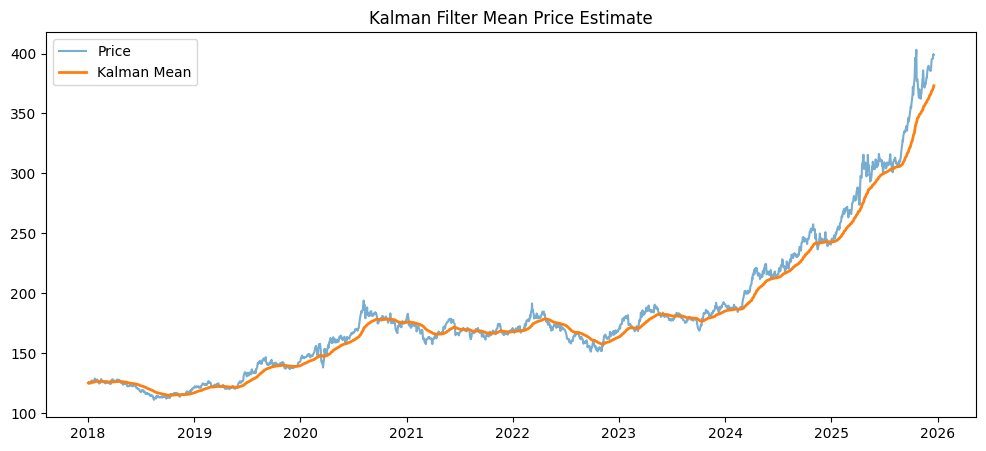

In [7]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

ticker = "GLD"
start = "2018-01-01"

raw = yf.download(ticker, start=start, auto_adjust=True, progress=False)

# --- Make a clean 1D price series ---
price = raw["Close"]
if isinstance(price, pd.DataFrame):      # happens when columns are multi / include ticker level
    price = price[ticker]
df = price.to_frame("price").dropna()

# Kalman parameters
Q = 1e-5  # process variance (how much the true mean can move)
R = 1e-2  # measurement variance (noise in observed prices)

n = len(df)
m = np.zeros(n)  # estimated mean
P = np.zeros(n)  # variance of estimate

m[0] = df["price"].iloc[0]
P[0] = 1.0

for t in range(1, n):
    # Predict step
    m_pred = m[t - 1]
    P_pred = P[t - 1] + Q

    # Observation at time t (IMPORTANT: use t, not 1)
    y = df["price"].iloc[t]

    # Update step
    K = P_pred / (P_pred + R)        # Kalman gain
    m[t] = m_pred + K * (y - m_pred) # mean update
    P[t] = (1 - K) * P_pred          # variance update

df["kalman_mean"] = m
df["deviation"] = df["price"] - df["kalman_mean"]

plt.figure(figsize=(12, 5))
plt.plot(df["price"], label="Price", alpha=0.6)
plt.plot(df["kalman_mean"], label="Kalman Mean", linewidth=2)
plt.legend()
plt.title("Kalman Filter Mean Price Estimate")
plt.show()
#Pg 105


### Buy-On-Gap Model
---

## 1
Select all stocks near the market open whose returns from their 
previous day’s lows to today’s opens are lower than one standard 
deviation. The standard deviation is computed using the daily close
to-close returns of the last 90 days. These are the stocks that “gapped 
down.” 

## 2 
Narrow down this list of stocks by requiring their open prices to be 
higher than the 20-day moving average of the closing prices. 

## 3
Buy the 10 stocks within this list that have the lowest returns from their 
previous day’s lows. If the list has fewer than 10 stocks, then buy the 
entire list.

## 4
Liquidate all positions at the market close

In [ ]:
#Buy-On-Gap Strategy implementation on top 100 US stocks
import numpy as np
import pandas as pd
import yfinance as yf

LOOKBACK_VOL = 90
MA_WINDOW = 20
TOP_N = 10
START = "2020-01-01"


tickers= [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "GOOG", "META", "BRK-B", "LLY", "TSLA",
    "JPM", "V", "XOM", "UNH", "MA", "AVGO", "HD", "PG", "COST", "MRK",
    "ABBV", "PEP", "KO", "BAC", "ADBE", "CRM", "ORCL", "CVX", "NFLX", "WMT",
    "AMD", "INTC", "QCOM", "TXN", "CSCO", "TMO", "ABT", "ACN", "MCD", "DHR",
    "DIS", "LIN", "NKE", "PM", "UPS", "LOW", "INTU", "RTX", "NEE", "HON",
    "MS", "GS", "IBM", "AMAT", "CAT", "BLK", "GE", "SBUX", "ISRG", "SPGI",
    "ELV", "DE", "PFE", "BKNG", "AXP", "MDT", "ADI", "AMGN", "CB", "GILD",
    "LRCX", "CI", "SYK", "MMC", "VRTX", "ZTS", "TJX", "SCHW", "MU", "NOW",
    "FISV", "PANW", "PLD", "CME", "ICE", "SO", "DUK", "TGT", "BDX", "APD"
]

raw = yf.download(
    tickers,
    start=START,
    auto_adjust=True,  
    progress=False,
    group_by="ticker"
)

def get_field(df, field):
    # Handles both column orderings robustly
    if isinstance(df.columns, pd.MultiIndex):
        # try common patterns
        if field in df.columns.get_level_values(0):
            # columns like (field, ticker)
            out = df[field]
            out.columns.name = None
            return out
        elif field in df.columns.get_level_values(1):
            # columns like (ticker, field)
            out = df.xs(field, axis=1, level=1)
            out.columns.name = None
            return out
    # single-ticker case: columns are just Open/High/Low/Close
    if field in df.columns:
        return df[[field]].rename(columns={field: tickers[0]})
    raise ValueError("Could not parse yfinance columns. Print raw.columns to inspect.")

open_px  = get_field(raw, "Open")
high_px  = get_field(raw, "High")
low_px   = get_field(raw, "Low")
close_px = get_field(raw, "Close")

open_px, low_px = open_px.align(low_px, join="inner", axis=0)
open_px, close_px = open_px.align(close_px, join="inner", axis=0)

# Step 1: Identify "gapped down" stocks
# -----------------------------
# Gap return from previous day's LOW to today's OPEN:
# gap_ret[t] = Open[t] / Low[t-1] - 1
gap_ret = open_px / low_px.shift(1) - 1

cc_ret = close_px.pct_change()
vol90 = cc_ret.rolling(LOOKBACK_VOL).std()

#Condition: gapped down more than 1 std dev
# i.e., gap_ret < -vol90  (negative and large in magnitude)
gap_down_mask = gap_ret < (-vol90)

# Step 2: Require open > 20-day moving average of CLOSE
ma20 = close_px.rolling(MA_WINDOW).mean()
trend_mask = open_px > ma20

eligible = gap_down_mask & trend_mask

# Step 3: Each day, buy up to 10 stocks with lowest gap_ret
intraday_ret = close_px / open_px -1

dates = close_px.index
portfolio_ret = pd.Series(index=dates, dtype=float)

picks_each_day = {}

for t in range(len(dates)):
    dt = dates[t]

    #Need yesterday's low for gap_ret, and enough lookback for vol90/ma20
    if pd.isna(vol90.loc[dt]).all():
        portfolio_ret.loc[dt] = 0.0
        continue

    elig_today = eligible.loc[dt]
    if elig_today.sum() == 0:
        portfolio_ret.loc[dt] = 0.0
        continue

    candidates = gap_ret.loc[dt][elig_today]

    picks = candidates.nsmallest(TOP_N).index.tolist()
    picks_each_day[dt] = picks
    
    day_rets = intraday_ret.loc[dt,picks].dropna()
    if len(day_rets) == 0:
         portfolio_ret.loc[dt] = 0.0
    else:
        portfolio_ret.loc[dt] = day_rets.mean()

# Step 4: Equity curve + basic metrics
equity = (1 + portfolio_ret.fillna(0)).cumprod()

def perf_stats(daily_ret, ann_factor=252):
    daily_ret = daily_ret.dropna()
    apr = (1 + daily_ret).prod() ** (ann_factor / len(daily_ret)) - 1
    sharpe = (daily_ret.mean() / daily_ret.std()) * np.sqrt(ann_factor) if daily_ret.std() > 0 else np.nan
    peak = (1 + daily_ret).cumprod().cummax()
    curve = (1 + daily_ret).cumprod()
    max_dd = (curve / peak - 1).min()
    return apr, sharpe, max_dd

apr, sharpe, max_dd = perf_stats(portfolio_ret)

print("====================================")
print(f"APR (approx): {apr:.3f}  -> {apr*100:.1f}%")
print(f"Sharpe:       {sharpe:.3f}")
print(f"Max Drawdown: {max_dd:.3f} -> {max_dd*100:.1f}%")
print("====================================")
#pg 113 

APR (approx): -0.025  -> -2.5%
Sharpe:       -0.217
Max Drawdown: -0.172 -> -17.2%


In [4]:
#Cross-Sectional Mean Reversion on S&P500
#   Trade *relative* over/under-performance across a universe (S&P 500).
#   If a stock outperformed its peers today, we *short* it (expecting it to cool off).
#   If a stock underperformed its peers today, we *buy* it (expecting it to bounce).
#
# This is NOT "time-series mean reversion" (price reverting to its own mean).
# This is "cross-sectional mean reversion" (relative returns reverting).
#
# Book formula (Equation 4.1) for daily weights:
#
#   w_{t,i} = - ( r_{t,i} - <r_t> ) /  Σ_k | r_{t,k} - <r_t> |
#
# where:
#   r_{t,i}  = daily return of stock i on day t
#   <r_t>    = cross-sectional average return of all stocks that day (equal-weight)
#   Σ_k ...  = sum across all stocks k in the universe
#
# Why the minus sign?
#   If r_{t,i} is above the average <r_t>, then (r_{t,i} - <r_t>) is positive.
#   w_{t,i} becomes negative => you SHORT the outperformer (bet it mean-reverts).
#   Conversely, if a stock underperformed, w_{t,i} is positive => you go LONG it.
#
# Why the denominator?
#   It normalizes weights so that total *gross exposure* each day is 1:
#
#     Σ_i |w_{t,i}| = 1
#
# Proof:
#   Let d_{t,i} = r_{t,i} - <r_t>  (deviation from the daily cross-sectional mean)
#   Then w_{t,i} = - d_{t,i} / Σ_k |d_{t,k}|
#   So:
#     Σ_i |w_{t,i}| = Σ_i |d_{t,i}| / Σ_k |d_{t,k}| = 1
#
# Interpretation:
#   You always deploy the same total absolute capital each day (easy risk sizing),
#   regardless of how volatile the market is.
#
# How the portfolio return is computed:
#   If weights are w_{t,i} (capital allocated to stock i on day t),
#   and realized returns on the next day are r_{t+1,i},
#   then the portfolio return at day t+1 is:
#
#     R_{t+1} = Σ_i w_{t,i} * r_{t+1,i}
#
# That’s why we use weights.shift(1) when multiplying by ret:
#   We decide weights using day t info, and those weights earn day t->t+1 returns.
#   This avoids lookahead bias.
import numpy as np
import pandas as pd
import yfinance as yf
import requests
import warnings
warnings.filterwarnings("ignore")


#  Get S&P 500 tickers (current list)

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
sp500 = pd.read_html(requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text)[0]
tickers = sp500["Symbol"].str.replace(".", "-", regex=False).tolist()


# Download Adjusted Close in chunks (yfinance can struggle with 500 at once)
def download_adj_close(tickers, start="2020-01-01", chunk=80):
    parts = []
    for i in range(0, len(tickers), chunk):
        batch = tickers[i:i+chunk]
        raw = yf.download(batch, start=start, auto_adjust=True, progress=False)

        # For multi-ticker downloads, raw typically has MultiIndex columns: ('Close', 'AAPL'), etc.
        if isinstance(raw.columns, pd.MultiIndex):
            close = raw["Close"]
        else:
            # single ticker fallback
            close = raw[["Close"]].rename(columns={"Close": batch[0]})

        parts.append(close)

    close_px = pd.concat(parts, axis=1)
    close_px = close_px.loc[:, ~close_px.columns.duplicated()]
    return close_px

close_px = download_adj_close(tickers, start="2024-01-01")

#Compute daily returns r_{t,i}
# -----------------------------
# pct_change computes:
#   r_{t,i} = (P_{t,i} - P_{t-1,i}) / P_{t-1,i}
ret = close_px.pct_change()

#Compute cross-sectional average return <r_t>
# -----------------------------
# This is the equal-weight "market" return across the universe:
#   <r_t> = (1/N) Σ_i r_{t,i}
#
# Using skipna=True prevents missing tickers from breaking the mean.
market_ret = ret.mean(axis=1, skipna=True)

#Compute deviations from the cross-sectional mean
# -----------------------------
# For each day t and stock i:
#   d_{t,i} = r_{t,i} - <r_t>
#
# These are the "relative returns" (out/under-performance vs peers).
excess = ret.sub(market_ret, axis=0)

#Turn deviations into raw mean-reversion weights
# -----------------------------
# Eq (4.1) numerator:
#   w_raw_{t,i} = -(r_{t,i} - <r_t>) = -d_{t,i}
#
# So:
#   - if a stock outperformed (d positive), weight becomes negative => short
#   - if a stock underperformed (d negative), weight becomes positive => long
weights_raw = -excess

#Normalize weights so gross exposure is 1 each day
# -----------------------------
# Denominator in Eq (4.1):
#   denom_t = Σ_k |r_{t,k} - <r_t>|
#
# Then:
#   w_{t,i} = w_raw_{t,i} / denom_t
#
# This makes Σ_i |w_{t,i}| = 1 (proof in header comment).
denom = weights_raw.abs().sum(axis=1)
weights = weights_raw.div(denom.replace(0,np.nan), axis=0).fillna(0.0)

# Compute portfolio daily returns (NO LOOKAHEAD)
# -----------------------------
# Book:
#   dailyret = sum(backshift(1, weights) .* ret, 2)
#
# Explanation:
#   - weights at time t are computed using returns at time t
#   - you can only trade AFTER you observe those returns (e.g., near close)
#   - so those weights should earn returns on the NEXT day
#
# Therefore we multiply by ret using weights.shift(1):
#   R_t = Σ_i w_{t-1,i} * r_{t,i}
daily_ret = (weights.shift(1) * ret).sum(axis=1, skipna=True)

# Build an equity curve (growth of $1)
# -----------------------------
# If your portfolio return on day t is R_t, then your capital evolves like:
#   equity_t = equity_{t-1} * (1 + R_t)
#
# cumprod computes the cumulative product over time.
equity = (1.0 + daily_ret.fillna(0.0)).cumprod()

#  Compute performance metrics: APR, Sharpe, Max Drawdown
ann = 252
r = daily_ret.dropna()

apr = r.mean() * ann
sharpe = np.sqrt(ann) * r.mean() / r.std(ddof=1) if r.std(ddof=1) != 0 else np.nan

running_max = equity.cummax()
max_dd = (equity / running_max - 1).min()

print("============================================================")
print("Cross-Sectional Mean Reversion (Eq. 4.1) on S&P 500")
print("------------------------------------------------------------")
print(f"Tickers used: {close_px.shape[1]}")
print(f"Date range:   {close_px.index.min().date()} -> {close_px.index.max().date()}")
print(f"APR:          {apr:.3f}  ({apr*100:.1f}%)")
print(f"Sharpe:       {sharpe:.3f}")
print(f"Max Drawdown: {max_dd:.3f} ({max_dd*100:.1f}%)")
print("============================================================")

# If you want: see which names were most long/short on the latest day
last_day = weights.index[-1]
top_longs = weights.loc[last_day].sort_values(ascending=False).head(10)
top_shorts = weights.loc[last_day].sort_values(ascending=True).head(10)

print("\nTop 10 LONG weights (latest day):")
print(top_longs)

print("\nTop 10 SHORT weights (latest day):")
print(top_shorts)

Cross-Sectional Mean Reversion (Eq. 4.1) on S&P 500
------------------------------------------------------------
Tickers used: 503
Date range:   2024-01-02 -> 2025-12-22
APR:          0.120  (12.0%)
Sharpe:       1.454
Max Drawdown: -0.070 (-7.0%)

Top 10 LONG weights (latest day):
Ticker
TPL     0.129197
STX     0.010011
DLTR    0.009290
D       0.008390
TGT     0.006747
LW      0.006220
NKE     0.006111
SBUX    0.005933
WDC     0.005818
TAP     0.005787
Name: 2025-12-22 00:00:00, dtype: float64

Top 10 SHORT weights (latest day):
Ticker
FSLR   -0.011517
NCLH   -0.009090
HII    -0.008464
STZ    -0.008408
PSKY   -0.007069
MU     -0.006531
SNPS   -0.006074
MRK    -0.005717
NEM    -0.005627
WBD    -0.005598
Name: 2025-12-22 00:00:00, dtype: float64


## Key Takeaways on Mean Reversion & Cross-Sectional Strategies

- **Be cautious with stock pair trading.**  
  While the large number of possible stock pairs can be tempting, changes in company fundamentals can easily break historical relationships. This often leads to poor *out-of-sample* performance, even when backtests look excellent.

- **ETF portfolios can outperform stock pairs.**  
  Trading a diversified portfolio of *cointegrating ETFs* is often more robust than pair-trading individual stocks, as ETFs naturally diversify idiosyncratic risk.

- **Watch out for futures roll returns in ETFs.**  
  When pair trading ETFs that hold futures (e.g., commodity ETFs), total returns are strongly affected by **roll yield**, not just spot price movements.

- **Seasonal and intraday mean reversion can be profitable.**  
  These effects are often difficult to detect using standard stationarity or cointegration tests, yet they can be highly profitable in practice.

- **Momentum filters improve mean-reversion strategies.**  
  Adding a momentum or trend filter to a mean-reversion strategy typically improves consistency and reduces drawdowns.

- **Index arbitrage isn’t dead — it’s selective.**  
  If full index arbitrage between stocks and futures seems unprofitable, consider applying the strategy only to a *subset* of index constituents.

- **Cross-sectional mean reversion is easy to implement.**  
  These strategies can be expressed cleanly as **linear long–short portfolios**, making them both intuitive and scalable.

- **Relative return is not the only ranking signal.**  
  While relative return is the most common ranking variable, cross-sectional strategies can also use **fundamental factors** such as P/E ratio, valuation metrics, or quality measures.


### 4 Main Momentum causes:

## 1. 
For futures, the persistence of roll returns, especially of their signs

## 2. 
The slow diffusion, analysis, and acceptance of new information

## 3. 
The forced sales or purchases of assets of various types of funds

## 4. 
Market manipulation by high-frequency traders
pg151

 Time-Series Momentum Test (Correlation Scan)

**Goal:** Check whether a stock shows *time-series momentum* at specific horizons by testing:

- **Lagged return** over a look-back window `L` days  
  \[
  r^{lag}_t = \frac{P_t - P_{t-L}}{P_{t-L}}
  \]
- **Future return** over a holding window `H` days  
  \[
  r^{fut}_t = \frac{P_{t+H} - P_t}{P_t}
  \]

Then compute:
\[
\text{corr}(r^{lag}_t, r^{fut}_t)
\]
and a **p-value** for the null hypothesis **H₀: correlation = 0**.

## Important: Avoid overlapping return pairs
If we used every day `t`, the return pairs overlap heavily, which can inflate significance.
So we subsample indices spaced by `step = max(L, H)` so the pairs are roughly independent.

## Output
A table of `(lookback=L, hold=H, corr, pval, n)` to see:
- where correlation is most positive
- where p-values are small (more significant)

⚠️ This is **research** (uses realized future returns to test a hypothesis).  
A live strategy would use only the lagged return as the signal, then hold for `H` days.

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
import yfinance as yf

def fetch_close(ticker: str, start="2015-01-01", end=None) -> pd.Series:
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)
    if df.empty:
        raise ValueError("No data returned. Check ticker or date range.")
    close = df["Close"].dropna()
    close.name = "close"
    return close

def ts_momentum_correlation_scan(
    close,
    lookbacks=(1, 5, 10, 20, 60, 120, 250),
    holds=(1, 5, 10, 20, 60, 120, 250),
    use_signs=False,
) -> pd.DataFrame:
    """
    corr( lagged_return(L), future_return(H) ), using non-overlapping sampling.
    Robust to close being a DataFrame or other shape.
    """

    # --- Force close into a 1-D Series ---
    if isinstance(close, pd.DataFrame):
        if close.shape[1] != 1:
            raise ValueError(f"`close` has {close.shape[1]} columns; pass a single close series.")
        close = close.iloc[:, 0]

    close = pd.Series(close).astype(float).dropna()
    close = close[~close.index.duplicated(keep="first")]  # just in case
    px = close

    results = []
    n = len(px)

    for L in lookbacks:
        for H in holds:
            if L <= 0 or H <= 0:
                continue
            if n <= max(L, H) + 5:
                continue

            # lagged return: (P_t - P_{t-L}) / P_{t-L}
            ret_lag = px.pct_change(periods=L)

            # future return: (P_{t+H} - P_t) / P_t
            ret_fut = px.shift(-H) / px - 1.0

            # robust alignment
            df = pd.concat(
                [ret_lag.rename("ret_lag"), ret_fut.rename("ret_fut")],
                axis=1
            ).dropna()

            if df.empty:
                continue

            # non-overlapping sampling
            step = max(L, H)
            indep = df.iloc[::step]

            x = np.sign(indep["ret_lag"].to_numpy()) if use_signs else indep["ret_lag"].to_numpy()
            y = np.sign(indep["ret_fut"].to_numpy()) if use_signs else indep["ret_fut"].to_numpy()

            if len(x) < 3:
                continue

            # skip constant arrays (pearsonr can’t handle)
            if np.all(x == x[0]) or np.all(y == y[0]):
                continue

            cc, pval = pearsonr(x, y)

            results.append(
                {"lookback": L, "hold": H, "corr": cc, "pval": pval, "n_indep": len(x),
                 "mode": "signs" if use_signs else "returns"}
            )

    out = pd.DataFrame(results)
    if out.empty:
        return out

    return out.sort_values(["pval", "corr"], ascending=[True, False]).reset_index(drop=True)


# ---- Run it on one stock ----
ticker = "AAPL"
close = fetch_close(ticker, start="2010-01-01")

scan_returns = ts_momentum_correlation_scan(close, use_signs=False)
scan_signs   = ts_momentum_correlation_scan(close, use_signs=True)

print(f"{ticker} observations: {len(close)}")
print("\nTop 15 by (lowest p-value, highest corr) using RETURNS:")
display(scan_returns.head(15))

print("\nTop 15 by (lowest p-value, highest corr) using SIGNS:")
display(scan_signs.head(15))


AAPL observations: 4021

Top 15 by (lowest p-value, highest corr) using RETURNS:


,lookback,hold,corr,pval,n_indep,mode
0,250,20,0.621365,0.010191,16,returns
1,250,10,0.572637,0.020431,16,returns
2,1,1,-0.033600,0.033171,4019,returns
3,1,20,0.143724,0.042319,200,returns
4,250,5,0.492234,0.052761,16,returns
5,1,5,0.067703,0.055144,803,returns
6,60,60,-0.223339,0.071452,66,returns
7,1,60,0.208003,0.093754,66,returns
8,5,10,-0.083563,0.094711,401,returns
9,120,60,-0.294920,0.095683,33,returns



Top 15 by (lowest p-value, highest corr) using SIGNS:


,lookback,hold,corr,pval,n_indep,mode
0,250,5,0.832050,0.000064,16,signs
1,250,10,0.620174,0.010379,16,signs
2,1,20,0.161414,0.022405,200,signs
3,10,10,0.109920,0.027740,401,signs
4,250,20,0.544705,0.029127,16,signs
5,1,5,0.057065,0.106122,803,signs
6,60,120,0.274725,0.121799,33,signs
7,10,20,0.108312,0.126848,200,signs
8,5,120,-0.255731,0.150879,33,signs
9,120,20,0.236111,0.185885,33,signs


# How to Interpret Time-Series Momentum Correlation Results

This table summarizes **statistical tests for time-series momentum**.  
Each row corresponds to one pair of:

- a **look-back period (L)** used to measure past returns  
- a **holding period (H)** over which future returns are evaluated  

The goal is to answer:

> *Do past returns over L days help predict future returns over H days?*

---

## Column-by-Column Interpretation

### 1. `lookback` (L)

**What it is:**  
Number of past trading days used to compute the momentum signal.

$$
r^{\text{lag}}_t = \frac{P_t - P_{t-L}}{P_{t-L}}
$$

**How to interpret:**
- Larger `lookback` → slower, longer-term trend
- Smaller `lookback` → short-term behavior (often mean-reverting)

This is the **only information a live strategy knows at time $t$**.

---

### 2. `hold` (H)

**What it is:**  
Number of future days over which returns are measured.

$$
r^{\text{fut}}_t = \frac{P_{t+H} - P_t}{P_t}
$$

**How to interpret:**
- Indicates how long momentum tends to persist
- Used **only for evaluation**, not as an input signal

A real strategy would enter at time $t$ and hold for $H$ days.

---

### 3. `corr` (Correlation Coefficient)

**What it is:**  
Pearson correlation between past returns and future returns.

$$
\text{corr}\!\left(r^{\text{lag}},\, r^{\text{fut}}\right)
$$

**How to interpret:**

| corr value | Meaning in finance |
|-----------|-------------------|
| $\approx 0.00$ | No predictability |
| $0.05$ – $0.10$ | Weak but real |
| $0.10$ – $0.20$ | Meaningful momentum |
| $> 0.20$ | Strong (rare in finance) |

- Positive → momentum  
- Negative → mean reversion  

Even **0.10 is economically important** in financial markets.

---

### 4. `pval` (p-value)

**What it is:**  
Probability of observing this correlation if the true correlation were zero.

**Null hypothesis:**

$$
H_0: \rho = 0 \quad \text{(random walk)}
$$

**How to interpret:**

| p-value | Interpretation |
|--------|----------------|
| $< 0.01$ | Very strong evidence |
| $< 0.05$ | Statistically significant |
| $0.05$ – $0.10$ | Weak / borderline |
| $> 0.10$ | Likely noise |

Low p-values indicate the correlation is **unlikely to be due to chance**.

---

### 5. `n_indep` (Independent Observations)

**What it is:**  
Number of **non-overlapping return pairs** used in the test.

**Why it matters:**  
Overlapping returns inflate significance. This count reflects *statistically meaningful* samples.

**Rules of thumb:**

| n_indep | Reliability |
|--------|-------------|
| $< 20$ | Too small |
| $20$ – $50$ | Weak |
| $50$ – $100$ | Reasonable |
| $> 100$ | Strong |

---

### 6. `mode`

- `"returns"` → correlation of **return magnitudes**
- `"signs"` → correlation of **direction only** (+ / −)

If both modes show similar results, confidence in the signal increases.


# Kelly Formula

The **Kelly criterion** gives the optimal leverage (fraction of capital to invest)
when returns are assumed to be Gaussian.

---

## Formula

$$
f^* = \frac{\mu}{\sigma^2}
$$

---

## Definitions

- $f^*$ : optimal leverage (fraction of capital to invest)
- $\mu$ : **mean excess return**
  
  $$
  \mu = \mathbb{E}[R] - R_f
  $$

- $\sigma^2$ : **variance of excess returns**

---

## Derivation (Intuition)

The Kelly solution is obtained by maximizing expected log-wealth:

$$
\max_f \; \mathbb{E}\!\left[\log\left(1 + fR\right)\right]
$$

Under the assumption of normally distributed returns, this optimization leads to
the closed-form solution above.

---

## Interpretation

- Higher expected return $\Rightarrow$ higher optimal leverage
- Higher variance (risk) $\Rightarrow$ lower optimal leverage
- If $\mu \le 0$, the optimal Kelly leverage is **zero or negative**
